In [ ]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jrand

from gvabm.abm_event import conditional_sample, conditional_sample_noselection, conditional_sample_mixed
from gvabm.abm_ll import city_ll, eval_ds
from gvabm.stat_utils import logrange
from gvabm.param_distr import ParamDistr, param_config, mixed_choice_param_config, CityParams, EventOutcome, GeneralParams, MixedGeneralParams

In [1]:
from gvabm.city_data import subsampled_city_data
print(subsampled_city_data)

[{'events': [], 'params': CityParams(population=157, population_density=152.1, arm_count=80.0, arm_density=0.04076433121019108)}
 {'events': [], 'params': CityParams(population=199965, population_density=1546.2, arm_count=125.0, arm_density=0.06369426751592357)}
 {'events': [], 'params': CityParams(population=4277, population_density=1250.2, arm_count=67.0, arm_density=0.03414012738853503)}
 {'events': [], 'params': CityParams(population=1880, population_density=96.0, arm_count=26.0, arm_density=0.013248407643312102)}
 {'events': [], 'params': CityParams(population=2169, population_density=403.4, arm_count=96.00000000000001, arm_density=0.0489171974522293)}
 {'events': [], 'params': CityParams(population=1915031, population_density=1145.0, arm_count=111.00000000000001, arm_density=0.056560509554140125)}
 {'events': [EventOutcome(date='3/27/23', fatalities=6, injured=6, total_victims=12), EventOutcome(date='4/22/18', fatalities=4, injured=4, total_victims=8)], 'params': CityParams(popul

In [4]:
from gvabm.abm_vbmc import get_param_density_func_noisy
model_name = 'max_select'
sample_func = {'max_select': conditional_sample, 'sample_select': conditional_sample_noselection, 'mixed_choice': conditional_sample_mixed}[model_name]
param_config = {'max_select': param_config, 'sample_select': param_config, 'mixed_choice': mixed_choice_param_config}[model_name]
param_distr = ParamDistr(param_config)
prior = param_distr.get_uniform_prior()

density_func = get_param_density_func_noisy(sample_func, param_distr, jrand.PRNGKey(0), num_samples=10000)
P = density_func

from pyvbmc import VBMC
D = param_distr.param_count
LB = np.full((1, D), -np.inf); UB = np.full((1, D), np.inf)
PLB = param_distr.range_lower.reshape((1, -1)); PUB = param_distr.range_upper.reshape((1, -1))
x0 = np.array([-7.49712599, 38.49844685,  0.70090904, -1.13903331, -4.42167238]) #hardcode first sample for convenience
P(x0)

Evaluating params: [-7.497126  38.498447   0.700909  -1.1390333 -4.4216723]
prior 9.5367386e-07
Log posterior: -897.847900390625


(Array(-897.8479, dtype=float32), 0.8)

In [ ]:
import matplotlib.pyplot as plt
import pickle
# with open('data/ll_eval_153.pkl', 'rb') as f: #Eval over all axis ll_eval_b4c26.pkl
# with open('data/ll_eval_dc111.pkl', 'rb') as f: #2D grid search over propensity, atrisk
with open('data/ll_eval_17a46.pkl', 'rb') as f: #2D grid search over propensity, atrisk
    ll_eval = pickle.load(f)

In [2]:
import numpy as np
import pickle
from stat_utils import CityParams, EventOutcome, GeneralParams
from city_data import subsampled_city_data, subsample_weights
n_event = np.array([len(c['events']) for c in subsampled_city_data])

In [3]:
total_ll = {params: (subsample_weights.reshape((-1, 1))*city_eval).sum(axis=0)[0] for params, city_eval in ll_eval.items()}
param_groups = [p for p in ll_eval]
ll_list = [(subsample_weights.reshape((-1, 1))*ll_eval[p]).sum(axis=0) for p in param_groups]
import pandas as pd
result_df = pd.DataFrame(param_groups)
eval_df = pd.DataFrame(ll_list)
result_df = pd.concat([result_df, eval_df], axis=1)
result_df['city_eval'] = [ll_eval[p] for p in param_groups]

np.float64(-inf)

In [5]:
lookup_df = result_df.set_index(['propensity',  'walk_radius',  'arm_bias',  'arm_weight',  'atrisk_gathering_rate'])
params = ['propensity',  'walk_radius',  'arm_bias',  'arm_weight',  'atrisk_gathering_rate']
param_val = [np.sort(result_df[p].unique()) for p in params]
param_grid = np.meshgrid(*param_val, indexing='ij')

In [6]:
from itertools import product
eval_grid = np.zeros(param_grid[0].shape).flatten()
for i, p in enumerate(product(*param_val)):
    eval_grid[i] = lookup_df.loc[p][0]
eval_grid = eval_grid.reshape(param_grid[0].shape)

In [14]:
param_stack = np.stack([p for p in param_grid], axis=-1)
print(param_stack.shape, eval_grid.shape)

(10, 2, 2, 2, 10, 5) (10, 2, 2, 2, 10)


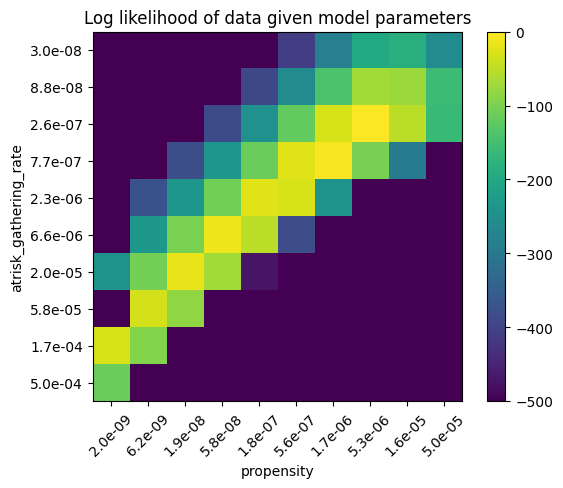

In [44]:
eval_slice = eval_grid.max(axis=1).max(axis=1).max(axis=1)  # Slice over walk_radius, arm_bias, arm_weight
eval_slice = eval_grid[:, 1, 1, 1, :]  # Slice over walk_radius, arm_bias, arm_weight

Z = eval_slice
mat = Z - Z.max()
cutoff = -500
mat[np.isneginf(mat)] = cutoff
mat = mat*(mat > cutoff) + cutoff*(mat <= cutoff)

plt.imshow(mat)
plt.xticks(range(len(param_val[0])), ['%.1e' % p for p in param_val[0]], rotation=45)
plt.yticks(range(len(param_val[4])), ['%.1e' % p for p in param_val[4]])
plt.xlabel('propensity')
plt.ylabel('atrisk_gathering_rate')
plt.colorbar()
plt.title('Log likelihood of data given model parameters')
plt.show()

In [38]:
X = param_stack.reshape(-1, param_stack.shape[-1])
y = eval_grid.flatten()

In [42]:
#set negative inf to minimum non-inf value
min_noninf = y[np.isfinite(y)].min()
y[~np.isfinite(y)] = min_noninf - 10.0

In [40]:
import numpy as np
from itertools import combinations_with_replacement
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def quadratic_features(X):
    """
    Build quadratic feature matrix for X.
    Includes constant, linear, and quadratic terms.
    """
    n, d = X.shape
    feats = [np.ones((n, 1))]        # constant
    feats.append(X)                  # linear terms

    # quadratic terms (i <= j to avoid duplicates)
    quad_terms = []
    for i, j in combinations_with_replacement(range(d), 2):
        quad_terms.append((X[:, i] * X[:, j])[:, None])
    feats.append(np.hstack(quad_terms))

    return np.hstack(feats)

import numpy as np
from itertools import combinations_with_replacement
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def quadratic_features(X):
    """
    Build quadratic feature matrix for X.
    Includes constant, linear, and quadratic terms.
    """
    n, d = X.shape
    feats = [np.ones((n, 1))]        # constant
    feats.append(X)                  # linear terms

    # quadratic terms (i <= j to avoid duplicates)
    quad_terms = []
    for i, j in combinations_with_replacement(range(d), 2):
        quad_terms.append((X[:, i] * X[:, j])[:, None])
    feats.append(np.hstack(quad_terms))

    return np.hstack(feats)


def fit_quadratic(X, y):
    """
    Fit quadratic model y ≈ c + b^T x + 0.5 x^T A x

    Returns
    -------
    c : float
        Constant term
    b : array, shape (d,)
        Linear coefficients
    A : array, shape (d, d)
        Symmetric quadratic matrix
    errors : dict
        MSE, RMSE, R^2
    """
    n, d = X.shape
    Phi = quadratic_features(X)

    # Fit regression
    reg = LinearRegression(fit_intercept=False)
    reg.fit(Phi, y)
    y_pred = reg.predict(Phi)

    # Extract parameters
    coef = reg.coef_

    c = coef[0]
    b = coef[1:1+d]

    A = np.zeros((d, d))
    idx = 1 + d
    for i, j in combinations_with_replacement(range(d), 2):
        A[i, j] = coef[idx]
        A[j, i] = coef[idx]  # symmetric
        idx += 1

    # Error metrics
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    errors = {"MSE": mse, "RMSE": rmse, "R2": r2}

    return c, b, A, errors

In [41]:
c, b, A, errors = fit_quadratic(X, y)

print("Fitted constant:", c)
print("Fitted linear b:", b)
print("Fitted quadratic A:\n", A)
print("Errors:", errors)

Fitted constant: -316509.5489567125
Fitted linear b: [ 5.56263805e+08  8.81411675e+03 -6.52192301e+04  5.24747690e+04
  2.02400948e+09]
Fitted quadratic A:
 [[ 2.72662015e+04 -7.53014024e+07  6.64226484e+08 -4.69511929e+08
  -1.69336405e+13]
 [-7.53014024e+07 -5.70997005e+01 -1.18151027e+03 -4.59355564e+03
  -1.69699589e+07]
 [ 6.64226484e+08 -1.18151027e+03  9.70772187e+04  1.97243776e+05
  -7.42692153e+07]
 [-4.69511929e+08 -4.59355564e+03  1.97243776e+05  5.63902262e+03
  -1.15319216e+08]
 [-1.69336405e+13 -1.69699589e+07 -7.42692153e+07 -1.15319216e+08
  -2.48682246e+12]]
Errors: {'MSE': 45712893656.41354, 'RMSE': np.float64(213805.7381278939), 'R2': 0.17633533457764206}


In [21]:
mu, Sigma

(array([4.47888703e-08, 2.04601255e+01, 5.67705771e-01, 4.23865529e-02,
        1.30618266e-04]),
 array([[ 4.39374544e-16, -2.68046248e-07,  8.92041348e-10,
         -8.15552136e-11,  9.98099548e-13],
        [-2.68046248e-07,  2.04389539e+02, -6.78224282e-01,
          6.33371087e-02, -7.65104790e-04],
        [ 8.92041348e-10, -6.78224282e-01,  1.22186506e-01,
         -9.02978696e-04,  2.54097679e-06],
        [-8.15552136e-11,  6.33371087e-02, -9.02978696e-04,
          1.86590095e-03, -2.37609768e-07],
        [ 9.98099548e-13, -7.65104790e-04,  2.54097679e-06,
         -2.37609768e-07,  2.86652213e-09]]))

In [ ]:
# param_grid_tuples = [tuple(param_grids[i].flatten()) for i in range(len(param_grids))]

In [42]:
# result_df[0]
# plt.hist(result_df[0], bins=np.linspace(-4000, -400, 100))
# plt.show()

In [69]:
grid_height = {(p.propensity, p.atrisk_gathering_rate): ll for p, ll in total_ll.items()}
propensity_range = np.unique(result_df['propensity']); atrisk_range = np.unique(result_df['atrisk_gathering_rate'])
propensity_range.sort(); atrisk_range.sort()
Z = np.array([[grid_height.get((propensity_range[x], atrisk_range[y]), -np.inf) for x in range(len(propensity_range))] for y in range(len(atrisk_range))])


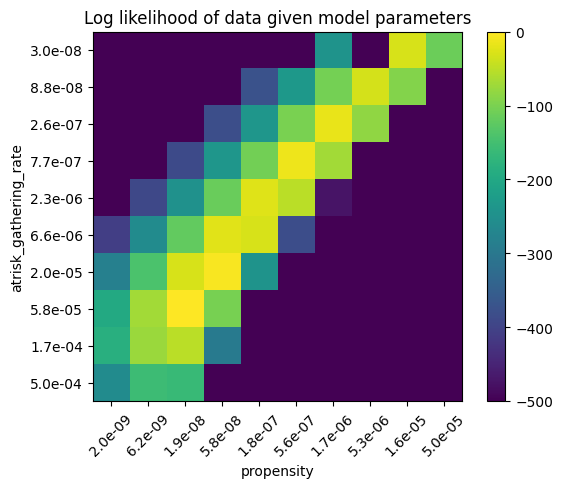

In [38]:
mat = Z - Z.max()
cutoff = -500
mat[np.isneginf(mat)] = cutoff
mat = mat*(mat > cutoff) + cutoff*(mat <= cutoff)

plt.imshow(mat)
plt.xticks(range(len(propensity_range)), ['%.1e' % p for p in propensity_range], rotation=45)
plt.yticks(range(len(atrisk_range)), ['%.1e' % p for p in atrisk_range])
plt.xlabel('propensity')
plt.ylabel('atrisk_gathering_rate')
plt.colorbar()
plt.title('Log likelihood of data given model parameters')
plt.show()

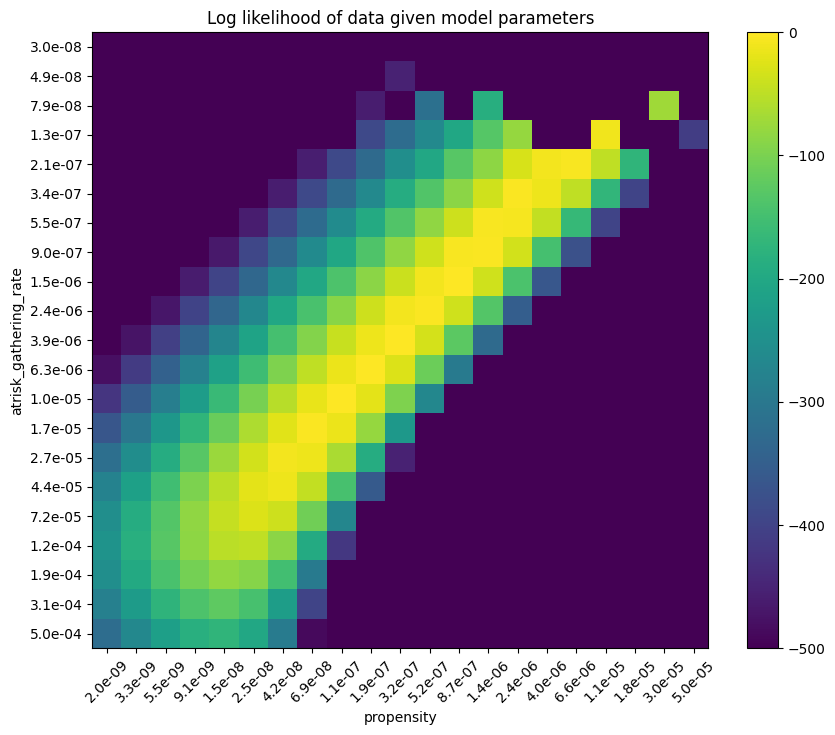

/tmp/ipykernel_1830307/1142763385.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


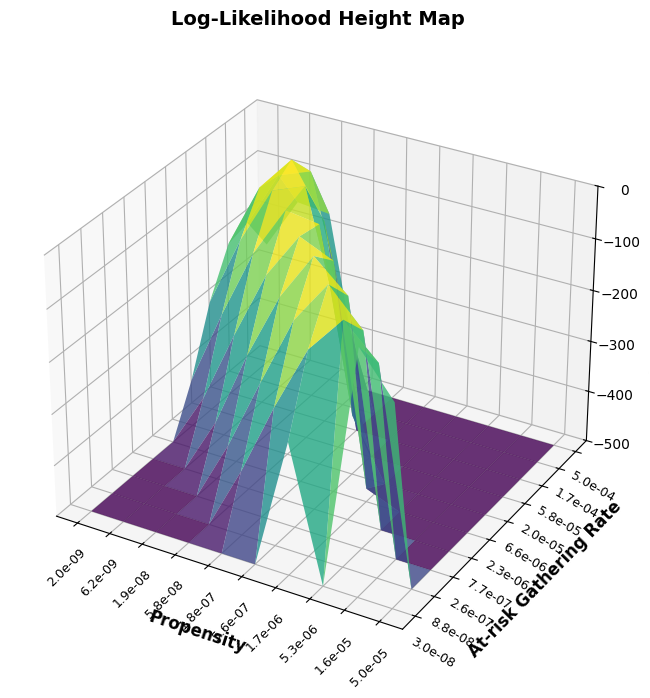

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib as mpl

# Assuming propensity_range, atrisk_range, and mat are already defined
# If not, you would define them here

# Set figure size and resolution
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 100

# Create figure with a specific aspect ratio
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create the meshgrid for plotting
X, Y = np.meshgrid(np.arange(len(propensity_range)), np.arange(len(atrisk_range)))

# Plot the surface with a professional colormap and lighting
surf = ax.plot_surface(
    X, Y, mat,
    cmap=cm.viridis,
    linewidth=0,
    antialiased=True,
    alpha=0.8,
    rstride=1,
    cstride=1,
)

# Customize the z-axis
ax.set_zlim(np.min(mat), np.max(mat))

# Add proper ticks for x and y axes using the actual range values
x_ticks = np.arange(len(propensity_range))
y_ticks = np.arange(len(atrisk_range))
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

# Set the actual values from propensity_range and atrisk_range as labels
# Comment out the next two lines if your ranges have too many values
ax.set_xticklabels([f"{p:.1e}" for p in propensity_range], fontsize=9, rotation=45)
ax.set_yticklabels([f"{a:.1e}" for a in atrisk_range], fontsize=9, rotation=-30)

# Add labels with better font styling
ax.set_xlabel('Propensity', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('At-risk Gathering Rate', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('Log Likelihood', fontsize=12, fontweight='bold', labelpad=10)

# Add a title
ax.set_title('Log-Likelihood Height Map', fontsize=14, fontweight='bold', pad=20)

# Customize the grid
ax.grid(True, linestyle='--', alpha=0.6)

# Adjust the view angle for better visibility
# ax.view_init(elev=30, azim=45)

# Adjust the axes aspect ratio
# Set z-axis scale the same as x, y
# Uncomment if you want uniform scaling
# ax.set_box_aspect([1, 1, 0.7])

# Tight layout
plt.tight_layout()

# Save the figure with high resolution
# plt.savefig('log_likelihood_heightmap.png', dpi=300, bbox_inches='tight')

plt.show()

In [85]:
slice_param = 'propensity'
param_cols = ['propensity', 'walk_radius', 'arm_bias', 'arm_weight', 'atrisk_gathering_rate']
param_cols.remove(slice_param)
grouped = result_df.groupby(param_cols)

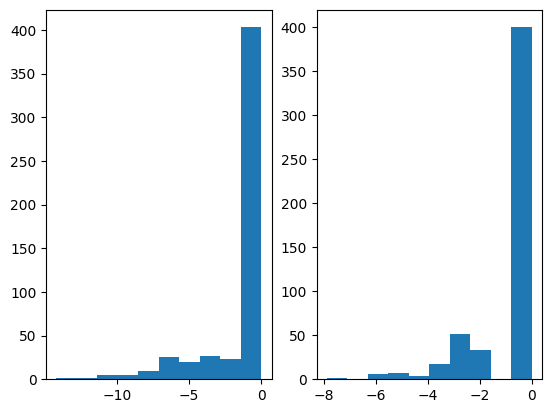

In [85]:
eval_slice_df = list(grouped)[30][1]
eval_slice_df
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2)
ind = 1
axes[0].hist(eval_slice_df.iloc[ind]['city_eval'][:, 1])
axes[1].hist(eval_slice_df.iloc[ind]['city_eval'][:, 2])
plt.show()


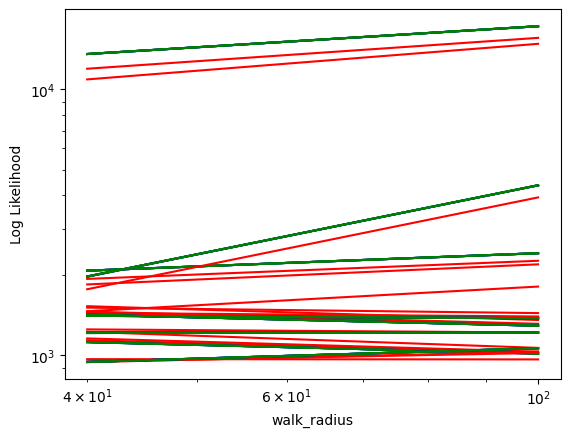

In [106]:
param_cols = ['propensity', 'walk_radius', 'arm_bias', 'arm_weight', 'atrisk_gathering_rate']
slice_param = 'walk_radius'
param_cols.remove(slice_param)
grouped = result_df.groupby(param_cols)
#Plot the log likelihood for each parameter group against the propensity
#Convert arm bias to color with a colorbar
import matplotlib.pyplot as plt
colorbar = plt.cm.ScalarMappable(cmap='viridis')
colormap = {0.01: 'red', 1: 'blue', 100: 'green'}

fig, ax = plt.subplots()
for name, group in grouped:
    # print(group)
    # print(group['arm_bias'].iloc[0])
    # if group['arm_bias'].iloc[0] in [1, 100]:
    #     continue
    ax.plot(group[slice_param], -group[0], c=colormap[group['arm_bias'].iloc[0]])
ax.set_xlabel(slice_param)
ax.set_ylabel('Log Likelihood')
ax.set_xscale('log'); ax.set_yscale('log')
# ax.legend()

/tmp/ipykernel_1199115/1978540426.py:11: MatplotlibDeprecationWarning: Passing label as a length 4 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(group[slice_param], -group[0], label=name)


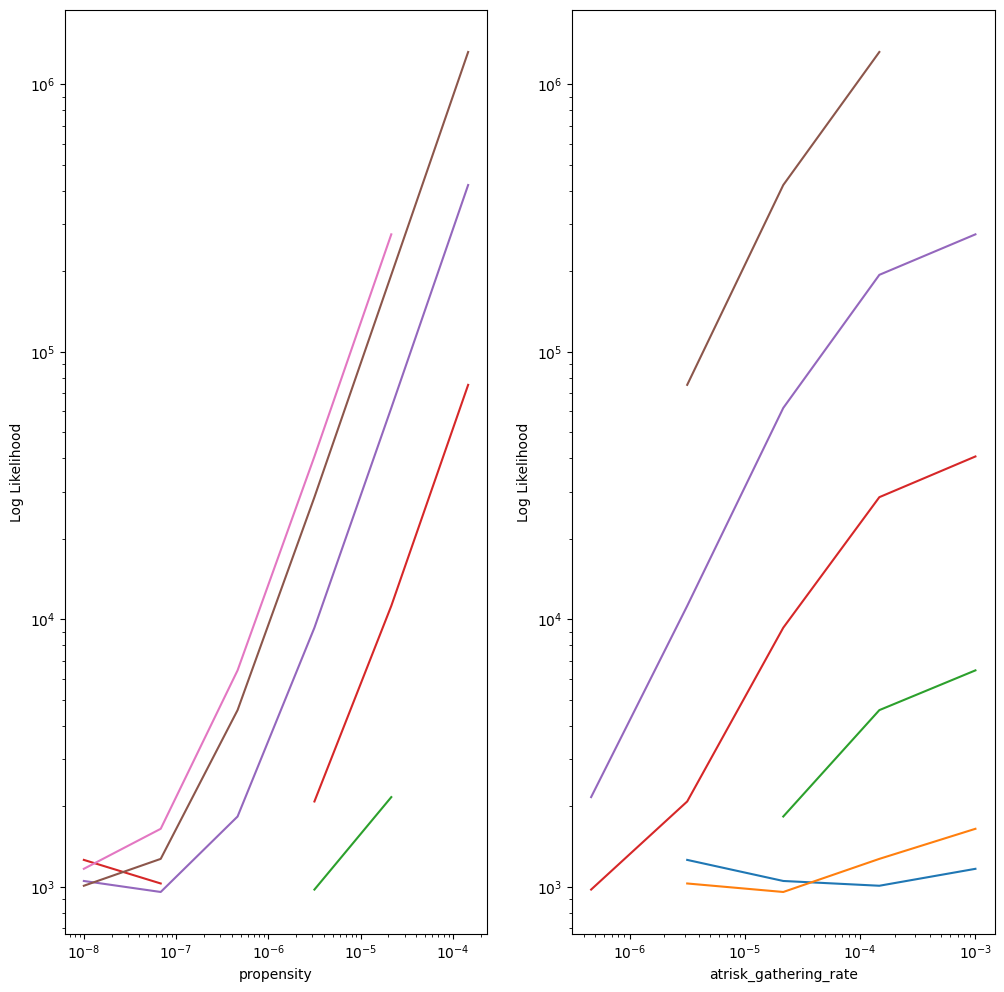

In [8]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 12))
for i, slice_param in enumerate(['propensity', 'atrisk_gathering_rate']):
    param_cols = ['propensity', 'walk_radius', 'arm_bias', 'arm_weight', 'atrisk_gathering_rate']
    param_cols.remove(slice_param)
    grouped = result_df.groupby(param_cols)
    #Plot the log likelihood for each parameter group against the propensity
    ax = axes.flatten()[i]
    for name, group in grouped:
        # print(group)
        ax.plot(group[slice_param], -group[0], label=name)
    ax.set_xlabel(slice_param)
    ax.set_ylabel('Log Likelihood')
    ax.set_xscale('log'); ax.set_yscale('log')
# plt.legend()

In [33]:
result_df.to_csv('ll_eval_df.csv', sep='\t')

,propensity,walk_radius,arm_bias,arm_weight,atrisk_gathering_rate,0,1,2,city_eval
0,1.000000e-09,100,100.00,10.0,0.01000,-1380.351081,-702.363248,-677.987833,"[[-11.386559463338571, -6.388017429059441, -4...."
1,1.000000e-09,100,100.00,10.0,0.00001,-1294.313663,-924.548481,-369.765182,"[[-11.686034708134471, -8.737510085076561, -2...."
2,1.000000e-09,100,100.00,1.0,0.01000,-1380.492305,-702.366285,-678.126020,"[[-11.37136184880398, -6.386509819584223, -4.9..."
3,1.000000e-09,100,100.00,1.0,0.00001,-1295.495239,-924.650576,-370.844663,"[[-11.675680015355386, -8.756645524987588, -2...."
4,1.000000e-09,100,100.00,0.1,0.01000,-1380.694062,-702.371623,-678.322439,"[[-11.386015411814927, -6.387891361773514, -4...."
...,...,...,...,...,...,...,...,...,...
136,1.000000e-06,40,1.00,0.1,0.01000,-13592.738040,-12915.558417,-677.179623,"[[-6.042699612758922, -1.0401257535510973, -5...."
137,1.000000e-06,40,1.00,0.1,0.00001,-1981.642327,-1620.087034,-361.555293,"[[-5.8181537599326045, -2.9939317261099427, -2..."
138,1.000000e-06,40,0.01,10.0,0.01000,-11965.191725,-11287.533260,-677.658465,"[[-6.022462020626551, -1.0406422789195824, -4...."
139,1.000000e-06,40,0.01,10.0,0.00001,-1773.899553,-1414.824390,-359.075163,"[[-5.615828918465159, -3.000477766308605, -2.6..."


In [ ]:

ll_values = np.array(list(total_ll.values()))
ll_values = ll_values[~np.isnan(ll_values) & (ll_values > -1000)]

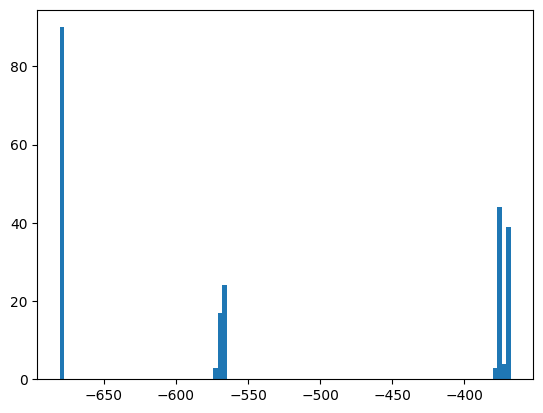

In [32]:
import matplotlib.pyplot as plt
plt.hist(ll_values, bins=100)
plt.show()